# Machine Learning - Regressão Linear
# Previsão da Expectativa de Vida por País

**Disciplina:** Tópicos Especiais em TI

**Técnica:** Aprendizado Supervisionado - Regressão Linear

**Dataset real (Kaggle):** Life Expectancy (WHO)
Fonte: https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who

### Sobre o dataset
Dados coletados pela Organização Mundial da Saúde (WHO) e pela ONU, contendo indicadores de
193 países entre os anos 2000 e 2015: mortalidade, escolaridade, PIB, vacinação, consumo de
álcool, entre outros.

### Objetivo
Construir um modelo de **regressão linear** capaz de prever a expectativa de vida de um país
a partir de indicadores de saúde e socioeconômicos, avaliando o modelo com R², RMSE e MAE.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style('whitegrid')

## 1. Carga e Limpeza dos Dados

In [2]:
df = pd.read_csv('Life_Expectancy_Data.csv')
df.columns = df.columns.str.strip()
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [3]:
df.shape

(2938, 22)

In [4]:
# Checando valores ausentes
df.isnull().sum().sort_values(ascending=False).head(10)

Population                         652
Hepatitis B                        553
GDP                                448
Total expenditure                  226
Alcohol                            194
Income composition of resources    167
Schooling                          163
thinness 1-19 years                 34
thinness 5-9 years                  34
BMI                                 34
dtype: int64

In [5]:
# Para a regressão, removemos linhas com valores ausentes nas colunas numéricas usadas
colunas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
df_limpo = df.dropna(subset=colunas_numericas).reset_index(drop=True)
print('Linhas antes:', df.shape[0], '| Linhas depois da limpeza:', df_limpo.shape[0])

Linhas antes: 2938 | Linhas depois da limpeza: 1649


In [6]:
df_limpo.describe().round(2)

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,1649.00,1649.0,1649.00,1649.00,1649.00,1649.00,1649.00,1649.00,1649.00,1649.00,1649.00,1649.00,1649.00,1649.00,1649.00,1.649000e+03,1649.00,1649.00,1649.00,1649.00
mean,2007.84,69.3,168.22,32.55,4.53,698.97,79.22,2224.49,38.13,44.22,83.56,5.96,84.16,1.98,5566.03,1.465363e+07,4.85,4.91,0.63,12.12
std,4.09,8.8,125.31,120.85,4.03,1759.23,25.60,10085.80,19.75,162.90,22.45,2.30,21.58,6.03,11475.90,7.046039e+07,4.60,4.65,0.18,2.80
min,2000.00,44.0,1.00,0.00,0.01,0.00,2.00,0.00,2.00,0.00,3.00,0.74,2.00,0.10,1.68,3.400000e+01,0.10,0.10,0.00,4.20
25%,2005.00,64.4,77.00,1.00,0.81,37.44,74.00,0.00,19.50,1.00,81.00,4.41,82.00,0.10,462.15,1.918970e+05,1.60,1.70,0.51,10.30
50%,2008.00,71.7,148.00,3.00,3.79,145.10,89.00,15.00,43.70,4.00,93.00,5.84,92.00,0.10,1592.57,1.419631e+06,3.00,3.20,0.67,12.30
75%,2011.00,75.0,227.00,22.00,7.34,509.39,96.00,373.00,55.80,29.00,97.00,7.47,97.00,0.70,4718.51,7.658972e+06,7.10,7.10,0.75,14.00
max,2015.00,89.0,723.00,1600.00,17.87,18961.35,99.00,131441.00,77.10,2100.00,99.00,14.39,99.00,50.60,119172.74,1.293859e+09,27.20,28.20,0.94,20.70


## 2. Análise Exploratória

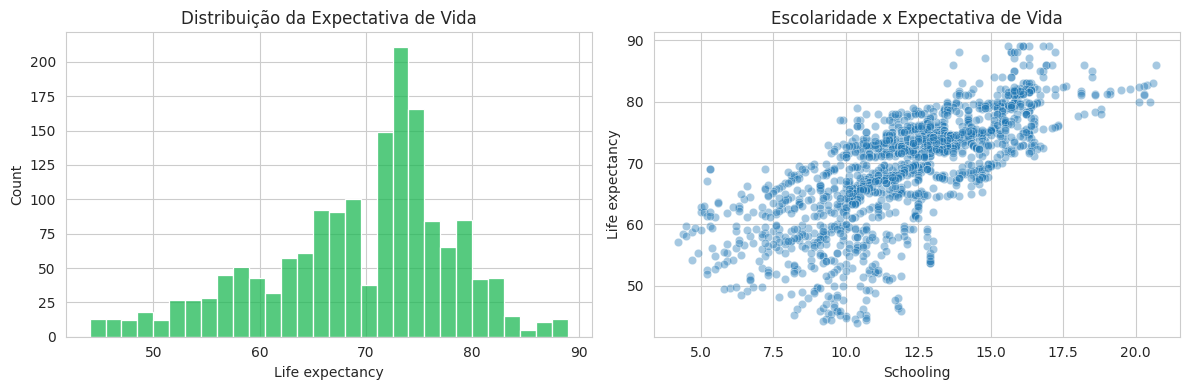

In [7]:
# Distribuição da variável alvo e sua relação com Escolaridade
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_limpo['Life expectancy'], bins=30, color='#1DB954', ax=axes[0])
axes[0].set_title('Distribuição da Expectativa de Vida')

sns.scatterplot(x='Schooling', y='Life expectancy', data=df_limpo, alpha=0.4, ax=axes[1])
axes[1].set_title('Escolaridade x Expectativa de Vida')
plt.tight_layout()
plt.show()

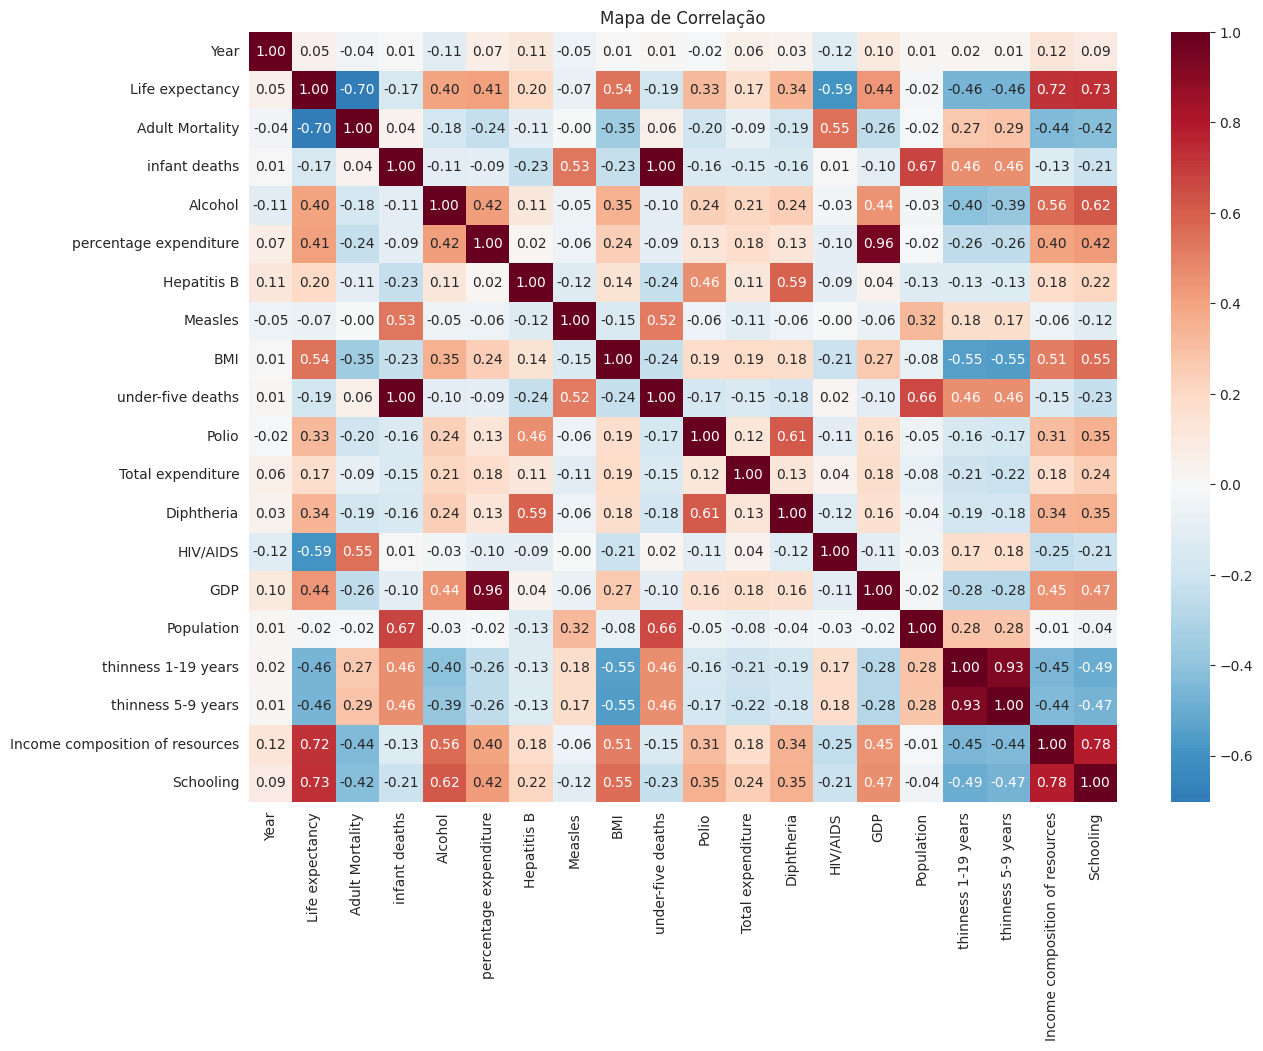

In [8]:
# Correlação entre as variáveis numéricas
plt.figure(figsize=(14, 10))
sns.heatmap(df_limpo[colunas_numericas].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Mapa de Correlação')
plt.show()

## 3. Seleção de Variáveis e Divisão Treino/Teste

In [9]:
# Selecionamos as variáveis com maior correlação (positiva ou negativa) com a expectativa de vida
features = ['Adult Mortality', 'HIV/AIDS', 'Income composition of resources', 'Schooling',
            'BMI', 'GDP', 'thinness 5-9 years']

X = df_limpo[features].values
y = df_limpo['Life expectancy'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
X_train.shape, X_test.shape

((1236, 7), (413, 7))

## 4. Treinando o Modelo de Regressão Linear

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f'R²:   {r2:.4f}')
print(f'RMSE: {rmse:.4f} anos')
print(f'MAE:  {mae:.4f} anos')

R²:   0.8079
RMSE: 3.7904 anos
MAE:  2.8790 anos


/tmp/ipykernel_124/4243090247.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variavel', data=coef_df, palette='coolwarm')


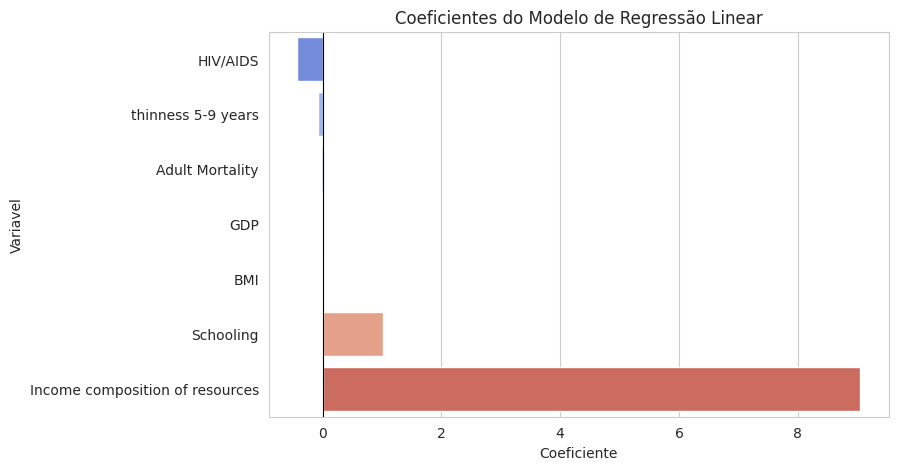

,Variavel,Coeficiente
1,HIV/AIDS,-0.434705
6,thinness 5-9 years,-0.081098
0,Adult Mortality,-0.018464
5,GDP,0.000051
4,BMI,0.026301
3,Schooling,1.024961
2,Income composition of resources,9.053344


In [11]:
# Coeficientes do modelo (impacto de cada variável na previsão)
coef_df = pd.DataFrame({'Variavel': features, 'Coeficiente': model.coef_}).sort_values('Coeficiente')

plt.figure(figsize=(8, 5))
sns.barplot(x='Coeficiente', y='Variavel', data=coef_df, palette='coolwarm')
plt.title('Coeficientes do Modelo de Regressão Linear')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

coef_df

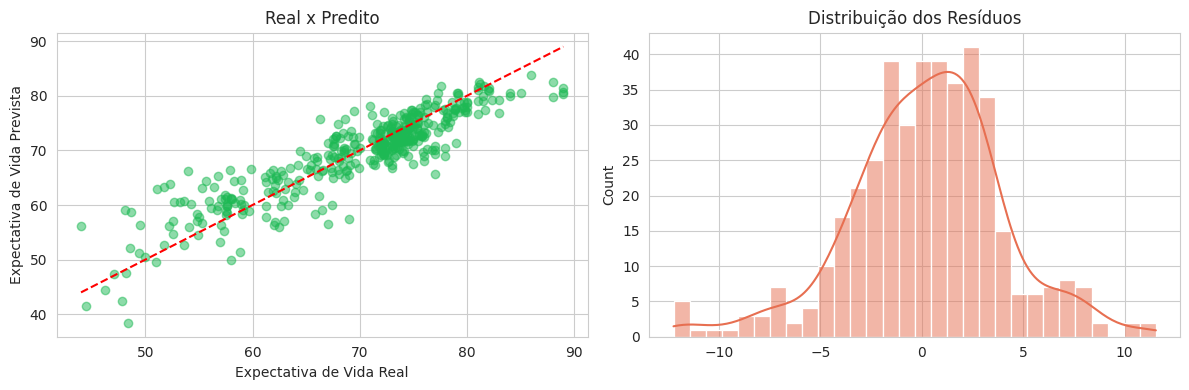

In [12]:
# Real x Predito e análise de resíduos
residuos = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_test, y_pred, alpha=0.5, color='#1DB954')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Expectativa de Vida Real')
axes[0].set_ylabel('Expectativa de Vida Prevista')
axes[0].set_title('Real x Predito')

sns.histplot(residuos, bins=30, kde=True, color='#e76f51', ax=axes[1])
axes[1].set_title('Distribuição dos Resíduos')
plt.tight_layout()
plt.show()

## 5. Equação do Modelo e Exemplo de Previsão

In [13]:
eq = f'expectativa_de_vida = {model.intercept_:.4f}'
for feat, coef in zip(features, model.coef_):
    eq += f' + ({coef:.4f} * {feat})'
print(eq)

expectativa_de_vida = 54.1826 + (-0.0185 * Adult Mortality) + (-0.4347 * HIV/AIDS) + (9.0533 * Income composition of resources) + (1.0250 * Schooling) + (0.0263 * BMI) + (0.0001 * GDP) + (-0.0811 * thinness 5-9 years)


In [14]:
# Exemplo: país com baixa mortalidade adulta, baixo HIV/AIDS, bom índice de renda e escolaridade
novo_pais = [[80, 0.1, 0.75, 13.5, 55, 15000, 2.0]]
previsao = model.predict(novo_pais)
print(f'Expectativa de vida prevista: {previsao[0]:.1f} anos')

Expectativa de vida prevista: 75.3 anos


## 6. Conclusão

O modelo de regressão linear conseguiu explicar boa parte da variação da expectativa de vida
entre os países usando indicadores de mortalidade, saúde e desenvolvimento socioeconômico.
Como esperado pela análise de correlação, **Mortalidade Adulta** e **HIV/AIDS** têm coeficientes
negativos (reduzem a expectativa de vida prevista), enquanto **Escolaridade** e **Índice de
Composição de Renda** têm coeficientes positivos (aumentam a previsão).